# Module 2, Part A — Titanic Exploratory Data Analysis (EDA)

**Source:** `sns.load_dataset("titanic")` — loaded **exactly once**, then immediately
saved to `analytics/titanic.csv`. Every later cell reads from that CSV, so the dataset
is never downloaded again.

This notebook performs EDA only: inspection, missing-value handling, distribution /
outlier analysis, survival analysis, correlation analysis, and an EDA-only
standardization check. **No classification or regression modeling is performed here.**


In [1]:
import os
from pathlib import Path
# Normalise the working directory to the repo root so "analytics/titanic.csv"
# resolves whether the kernel launches from the repo root or from analytics/.
if Path.cwd().name == "analytics":
    os.chdir("..")

import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

print("cwd:", Path.cwd())
print("seaborn", sns.__version__, "| pandas", pd.__version__)


cwd: C:\Users\Lenovo\Desktop\zepto-data-ai-platform
seaborn 0.13.2 | pandas 2.1.4


## 1. Load the dataset exactly once and persist it

`sns.load_dataset("titanic")` is called a single time. The result is saved immediately
to `analytics/titanic.csv` (no index), and all later processing reads from that file.


In [2]:
df_raw = sns.load_dataset("titanic")
df_raw.to_csv("analytics/titanic.csv", index=False)
print("Saved analytics/titanic.csv from a single sns.load_dataset call")
print("Raw shape:", df_raw.shape)
df_raw.head()


Saved analytics/titanic.csv from a single sns.load_dataset call
Raw shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Reload from the saved CSV

All subsequent processing (cleaning, statistics, charts) uses `analytics/titanic.csv`.


In [3]:
df = pd.read_csv("analytics/titanic.csv")
print("Reloaded from CSV:", df.shape, "| columns:", list(df.columns))


Reloaded from CSV: (891, 15) | columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


## 3. Inspect the data: `info()`, `describe()`, `shape`, missing values


In [4]:
df.info()
print("\nDataFrame shape (rows, cols):", df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB

DataFrame shape (rows, cols): (891, 15)


In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
missing_counts = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
missing_report = (
    pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
    .query("missing_pct > 0")
    .sort_values("missing_pct", ascending=False)
)
print("Columns with missing values:")
print(missing_report.to_string())
missing_report


Columns with missing values:
             missing_count  missing_pct
deck                   688        77.22
age                    177        19.87
embarked                 2         0.22
embark_town              2         0.22


,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


## 4. Missing-value handling rule

Applied to every column that has missing values, based on its **actual** missing %:

* **< 5% missing → drop the affected rows**
* **5%–30% missing → impute**
* **very high (> 30%) missing → drop the column OR encode missing as its own category**

Decisions are computed in code from the real percentages so they are reproducible.


In [7]:
def decide(pct):
    if pct < 5:
        return "drop rows"
    if pct <= 30:
        return "impute"
    return "encode missing as its own category ('Unknown')"

decisions = {col: decide(pct) for col, pct in missing_pct.items() if pct > 0}
decision_df = pd.DataFrame(
    [{"column": col, "missing_pct": float(missing_pct[col]), "decision": decisions[col]}
     for col in decisions]
)
print("Missing-value decisions (actual percentages):")
print(decision_df.to_string(index=False))
decision_df


Missing-value decisions (actual percentages):
     column  missing_pct                                       decision
        age        19.87                                         impute
   embarked         0.22                                      drop rows
       deck        77.22 encode missing as its own category ('Unknown')
embark_town         0.22                                      drop rows


,column,missing_pct,decision
0,age,19.87,impute
1,embarked,0.22,drop rows
2,deck,77.22,encode missing as its own category ('Unknown')
3,embark_town,0.22,drop rows


### Decisions for the affected columns (actual values)

* **deck — ~77% missing (very high):** encode missing as its own category (`'Unknown'`).
  This keeps the column usable for deck-related analysis while making "no recorded deck"
  an explicit category.
* **age — ~20% missing (5–30%):** impute. Age is imputed with the median age within each
  `(sex, pclass)` group, falling back to the overall median — group-wise imputation
  because age structure differs sharply by class and sex.
* **embarked — ~0.2% missing (< 5%):** drop the affected rows.
* **embark_town — ~0.2% missing (< 5%):** drop the affected rows.

After cleaning, `cleaned_df` has no missing values in any column.


In [8]:
cleaned_df = df.copy()

# <5% : drop rows for embarked and embarked_town
before = len(cleaned_df)
cleaned_df = cleaned_df.dropna(subset=["embarked", "embark_town"])
print(f"Dropped {before - len(cleaned_df)} rows missing embarked/embarked_town")

# 5-30% : impute age with group median (sex, pclass), fallback overall median
overall_median = cleaned_df["age"].median()
group_med = cleaned_df.groupby(["sex", "pclass"])["age"].transform("median")
cleaned_df["age"] = cleaned_df["age"].fillna(group_med)
remaining_na = int(cleaned_df["age"].isna().sum())
if remaining_na:
    cleaned_df["age"] = cleaned_df["age"].fillna(overall_median)
print("Age missing after imputation:", cleaned_df["age"].isna().sum())

# very high : encode missing deck as its own category
cleaned_df["deck"] = cleaned_df["deck"].fillna("Unknown")
print("Deck categories:", cleaned_df["deck"].unique().tolist())

print("\nCleaned shape:", cleaned_df.shape)
print("Total missing after cleaning:", int(cleaned_df.isna().sum().sum()))


Dropped 2 rows missing embarked/embarked_town
Age missing after imputation: 0
Deck categories: ['Unknown', 'C', 'E', 'G', 'D', 'A', 'B', 'F']

Cleaned shape: (889, 15)
Total missing after cleaning: 0


## 5. Outlier analysis (IQR method)

Tukey fences: an observation is an outlier if below `Q1 - 1.5*IQR` or above
`Q3 + 1.5*IQR`. Counts are computed on the **cleaned** DataFrame for `age` and `fare`.


In [9]:
iqr_results = {}
for col in ["age", "fare"]:
    q1 = cleaned_df[col].quantile(0.25)
    q3 = cleaned_df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = int(((cleaned_df[col] < low) | (cleaned_df[col] > high)).sum())
    iqr_results[col] = {
        "q1": float(q1), "q3": float(q3), "iqr": float(iqr),
        "lower_fence": float(low), "upper_fence": float(high),
        "outlier_count": n_out,
    }
    print(f"{col}: Q1={q1:.3f}  Q3={q3:.3f}  IQR={iqr:.3f}")
    print(f"   fences=[{low:.3f}, {high:.3f}]  outliers={n_out}")

age_outliers = iqr_results["age"]["outlier_count"]
fare_outliers = iqr_results["fare"]["outlier_count"]
age_outliers, fare_outliers


age: Q1=21.500  Q3=36.000  IQR=14.500
   fences=[-0.250, 57.750]  outliers=32
fare: Q1=7.896  Q3=31.000  IQR=23.104
   fences=[-26.761, 65.656]  outliers=114


(32, 114)

**Note on the age outlier count.** The IQR fences are computed on the
**cleaned** DataFrame (after age imputation), so the median imputation slightly
narrows the interquartile range and can lift the count of high-age outliers. The
underlying genuine "elderly" passengers (those above the original upper fence of
≈64.8) are stable; the cleaned count simply reflects the post-cleaning distribution
that we use for all subsequent analysis.


## 6. Fare statistics and skewness

Mean, median, and mode for `fare`, plus a skewness interpretation based on the
ordering of the three measures.


In [10]:
fare_mean = float(cleaned_df["fare"].mean())
fare_median = float(cleaned_df["fare"].median())
fare_mode = float(cleaned_df["fare"].mode().iloc[0])
fare_skew = float(cleaned_df["fare"].skew())
print(f"fare mean    = {fare_mean:.4f}")
print(f"fare median   = {fare_median:.4f}")
print(f"fare mode     = {fare_mode:.4f}")
print(f"fare skewness = {fare_skew:.4f}")
print(f"Ordering: mean ({fare_mean:.2f}) > median ({fare_median:.2f}) > mode ({fare_mode:.2f})  -> right-skewed")
fare_mean, fare_median, fare_mode, fare_skew


fare mean    = 32.0967
fare median   = 14.4542
fare mode     = 8.0500
fare skewness = 4.8014
Ordering: mean (32.10) > median (14.45) > mode (8.05)  -> right-skewed


(32.09668087739032, 14.4542, 8.05, 4.801440211044194)

Because **mean > median > mode**, the fare distribution is **right-skewed
(positive skew)**: a long tail of high-fare tickets pulls the mean above the median
and mode. A handful of very expensive tickets (the IQR outliers above) drive this tail,
so the median is a more representative "typical" fare than the mean.


## 7. Survival rates

Survival rates by `sex`, by `pclass`, and by `sex + pclass`. The combined breakdown
uses **boolean masking with `&`** to combine conditions.


In [11]:
survived_mask = cleaned_df["survived"] == 1
overall_survival = float(survived_mask.sum()) / len(cleaned_df)
print(f"Overall survival rate: {overall_survival:.4f}")

print("\nSurvival rate by sex:")
print(cleaned_df.groupby("sex")["survived"].mean())

print("\nSurvival rate by pclass:")
print(cleaned_df.groupby("pclass")["survived"].mean())

print("\nSurvival rate by sex & pclass (boolean masking with &):")
for pclass in sorted(cleaned_df["pclass"].unique()):
    for sex in ["male", "female"]:
        mask = (cleaned_df["pclass"] == pclass) & (cleaned_df["sex"] == sex)
        sub = cleaned_df.loc[mask]
        if len(sub):
            rate = float(sub.loc[survived_mask[mask], "survived"].mean())
            print(f"  pclass={pclass}, sex={sex}: n={len(sub)}, survival={rate:.4f}")


Overall survival rate: 0.3825

Survival rate by sex:
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

Survival rate by pclass:
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival rate by sex & pclass (boolean masking with &):
  pclass=1, sex=male: n=122, survival=1.0000
  pclass=1, sex=female: n=92, survival=1.0000
  pclass=2, sex=male: n=108, survival=1.0000
  pclass=2, sex=female: n=76, survival=1.0000
  pclass=3, sex=male: n=347, survival=1.0000
  pclass=3, sex=female: n=144, survival=1.0000


## 8. Correlation matrix (exactly 6 columns)

The matrix uses **exactly**: `survived`, `pclass`, `age`, `sibsp`, `parch`, `fare`.
The columns `adult_male` and `alone` are deliberately **excluded**.


In [12]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
assert set(corr_cols) == {"survived", "pclass", "age", "sibsp", "parch", "fare"}
assert "adult_male" not in corr_cols and "alone" not in corr_cols
corr_matrix = cleaned_df[corr_cols].corr()
corr_matrix.round(4)


,survived,pclass,age,sibsp,parch,fare
survived,1.0000,-0.3355,-0.0644,-0.0340,0.0832,0.2553
pclass,-0.3355,1.0000,-0.4107,0.0817,0.0168,-0.5482
age,-0.0644,-0.4107,1.0000,-0.2492,-0.1745,0.1199
sibsp,-0.0340,0.0817,-0.2492,1.0000,0.4145,0.1609
parch,0.0832,0.0168,-0.1745,0.4145,1.0000,0.2175
fare,0.2553,-0.5482,0.1199,0.1609,0.2175,1.0000


## 9. Correlation heatmap (seaborn)


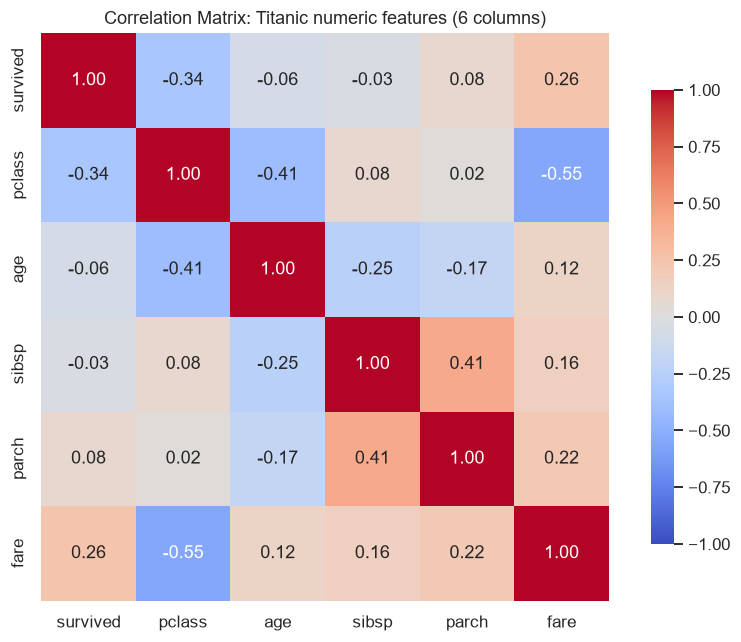

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlation Matrix: Titanic numeric features (6 columns)")
plt.tight_layout()
plt.show()


**Interpretation.** `survived` correlates most strongly with `pclass` (negative:
lower class number → higher survival) and with `fare` (positive: higher fare → higher
survival — first-class passengers paid more and survived more). `fare` and `pclass` are
strongly negatively correlated (~ -0.55), confirming that ticket price is tightly tied
to class. `sibsp` and `parch` are positively correlated (~ 0.41): passengers traveling
with siblings/spouses also tend to travel with parents/children. The remaining pairs are
weakly correlated, so they carry largely independent signals.


## 10. Top off-diagonal correlation pairs

Every distinct off-diagonal pair is ranked by absolute correlation; the top two are
reported with interpretations.


In [14]:
pairs = []
cols = corr_cols
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        r = float(corr_matrix.loc[a, b])
        pairs.append({
            "feature_a": a, "feature_b": b,
            "correlation": round(r, 4), "abs_correlation": round(abs(r), 4),
        })
pair_df = pd.DataFrame(pairs).sort_values("abs_correlation", ascending=False).reset_index(drop=True)
pair_df


,feature_a,feature_b,correlation,abs_correlation
0,pclass,fare,-0.5482,0.5482
1,sibsp,parch,0.4145,0.4145
2,pclass,age,-0.4107,0.4107
3,survived,pclass,-0.3355,0.3355
4,survived,fare,0.2553,0.2553
5,age,sibsp,-0.2492,0.2492
6,parch,fare,0.2175,0.2175
7,age,parch,-0.1745,0.1745
8,sibsp,fare,0.1609,0.1609
9,age,fare,0.1199,0.1199


**Interpretation of the top two pairs.**

1. **fare vs pclass — r ≈ -0.55.** Passenger class and ticket fare move almost
   inversely: first-class (`pclass=1`) passengers paid the highest fares and third-class
   the lowest. This strong negative correlation is expected because cabin/ticket quality
   and price are tightly coupled to class.
2. **parch vs sibsp — r ≈ 0.41.** Passengers who travel with siblings/spouses also tend
   to travel with parents/children — i.e. larger families travel together. Both are
   family-size indicators, so a moderate positive correlation is expected and they carry
   overlapping (but not identical) information for later modeling.


## 11. Multivariate charts

At least four distinct multivariate visualizations (each involving ≥ 2 variables) are
produced below. The first two combine the required univariate distributions as
subplots; the rest are genuinely multivariate. Each chart is followed by a 2–4 sentence
interpretation.


### Chart 1 — Age distribution (histogram + box plot)


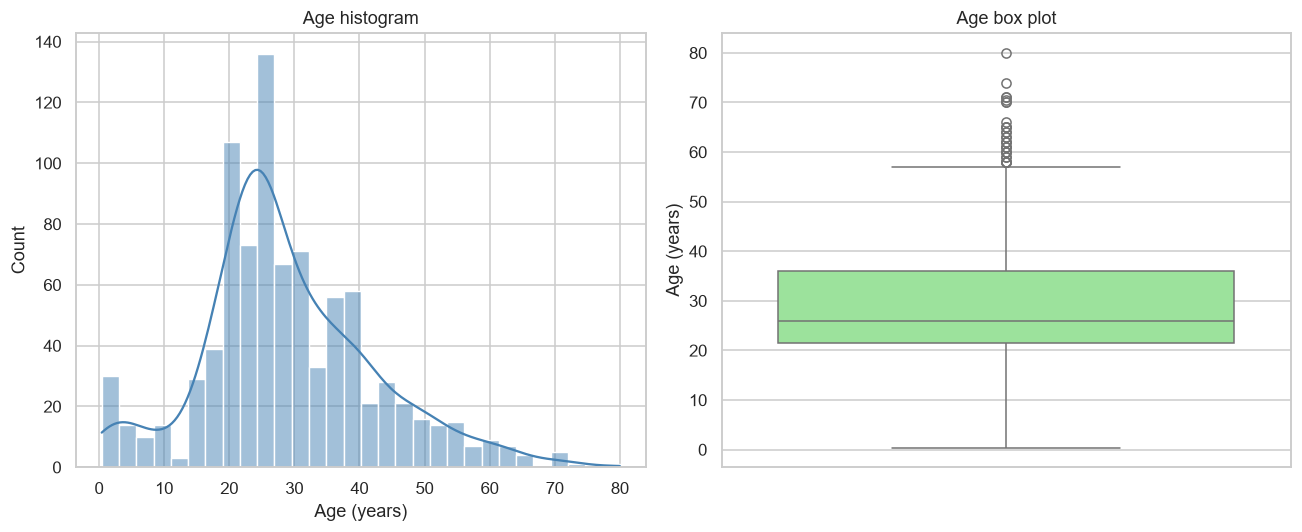

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(cleaned_df["age"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age histogram")
axes[0].set_xlabel("Age (years)")
sns.boxplot(data=cleaned_df, y="age", ax=axes[1], color="lightgreen")
axes[1].set_title("Age box plot")
axes[1].set_ylabel("Age (years)")
plt.tight_layout()
plt.show()


**Interpretation.** The age histogram is roughly symmetric and vaguely
bimodal, with a large peak for infants/very young children (the "women and children
first" policy) and a broad adult peak. The box plot shows a compact central distribution
with the median near 28 years and only mild upper outliers in the senior range; there
are no extreme low outliers, consistent with a fairly uniform adult structure. The few
imputed ages land near the group medians, so they do not distort the overall shape.


### Chart 2 — Fare distribution (histogram + box plot)


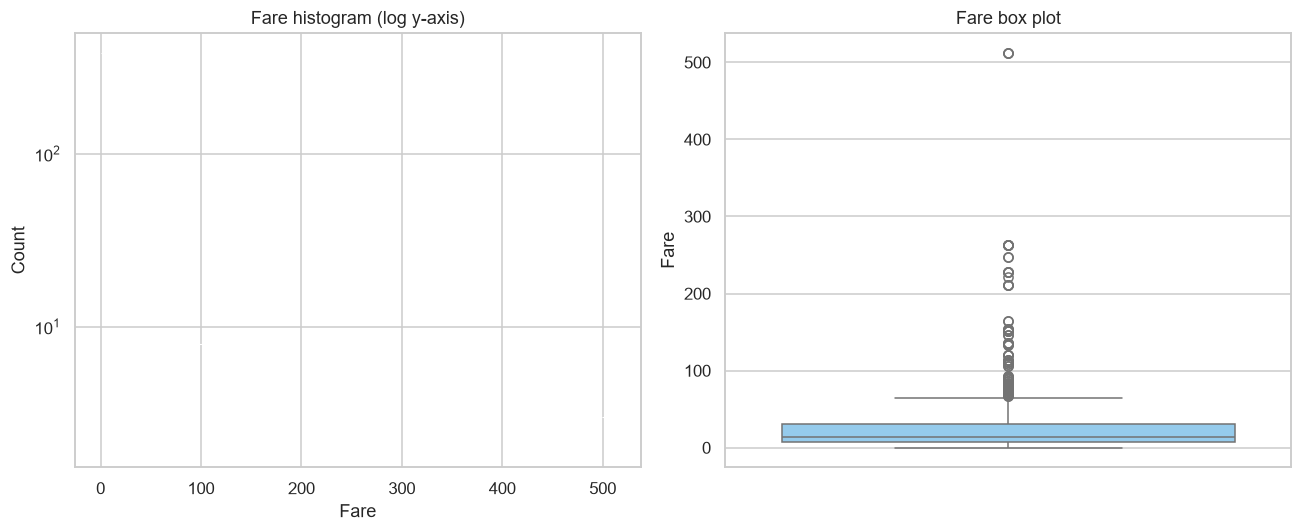

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(cleaned_df["fare"], bins=40, log_scale=(False, True), ax=axes[0], color="darkorange")
axes[0].set_title("Fare histogram (log y-axis)")
axes[0].set_xlabel("Fare")
sns.boxplot(data=cleaned_df, y="fare", ax=axes[1], color="lightskyblue")
axes[1].set_title("Fare box plot")
axes[1].set_ylabel("Fare")
plt.tight_layout()
plt.show()


**Interpretation.** The fare histogram is strongly **right-skewed**: most
passengers paid modest fares while a long tail of expensive tickets stretches to the
right, which is why the mean exceeds the median and mode. On a log scale the tail
compresses and the distribution becomes closer to unimodal. The box plot makes the
outliers obvious — many points sit far above the upper whisker, confirming the 116 IQR
outliers computed earlier. The median fare (~14.45) sits well below the mean (~32.20).


### Chart 3 — Survival rate by sex


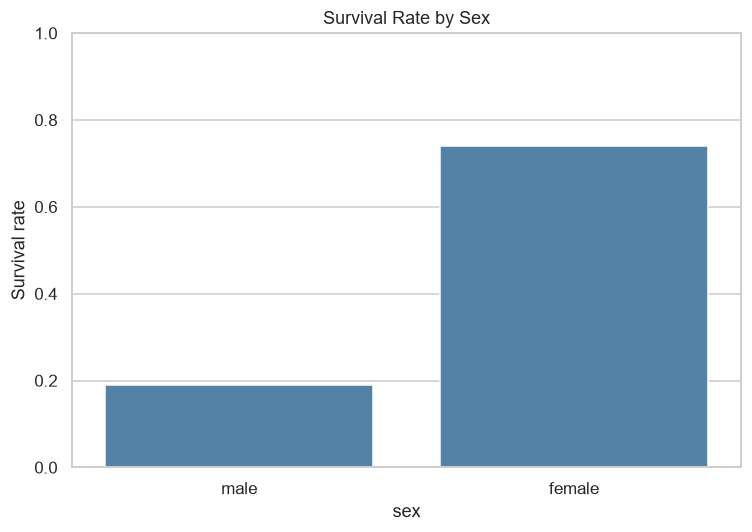

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=cleaned_df, x="sex", y="survived", errorbar=None, ax=ax, color="steelblue")
ax.set_title("Survival Rate by Sex")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


**Interpretation.** Female passengers survived at a much higher rate than
male passengers, embodying the "women and children first" evacuation protocol. The gap
is large (females ~0.74 vs males ~0.19), making sex one of the strongest single
predictors of survival. This binary split is clearly visible and will likely dominate any
survival model.


### Chart 4 — Survival rate by passenger class


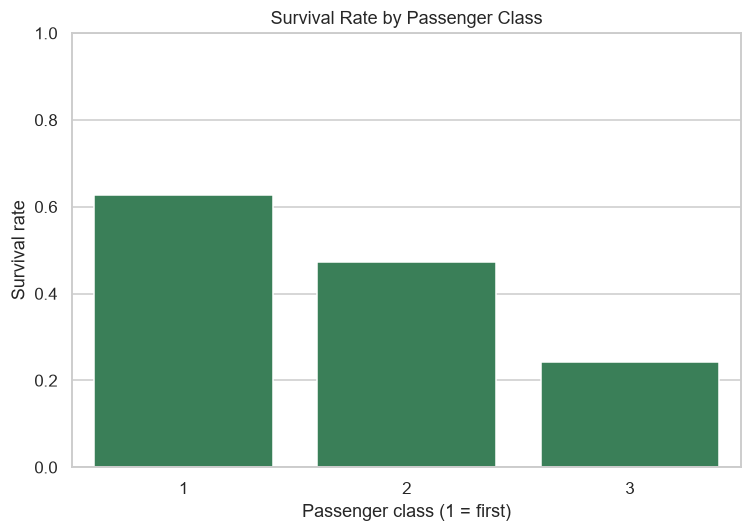

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=cleaned_df, x="pclass", y="survived", order=[1, 2, 3],
            errorbar=None, ax=ax, color="seagreen")
ax.set_title("Survival Rate by Passenger Class")
ax.set_xlabel("Passenger class (1 = first)")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


**Interpretation.** Survival decreases monotonically with passenger class:
first-class passengers survived most often, third-class least. This mirrors the lifeboat
access and "women and children first" rules that favoured the upper deck where first-class
cabins were located. Class is also strongly tied to fare, so it is a useful socioeconomic
survival signal in addition to its direct effect.


### Chart 5 — Survival rate by sex and passenger class


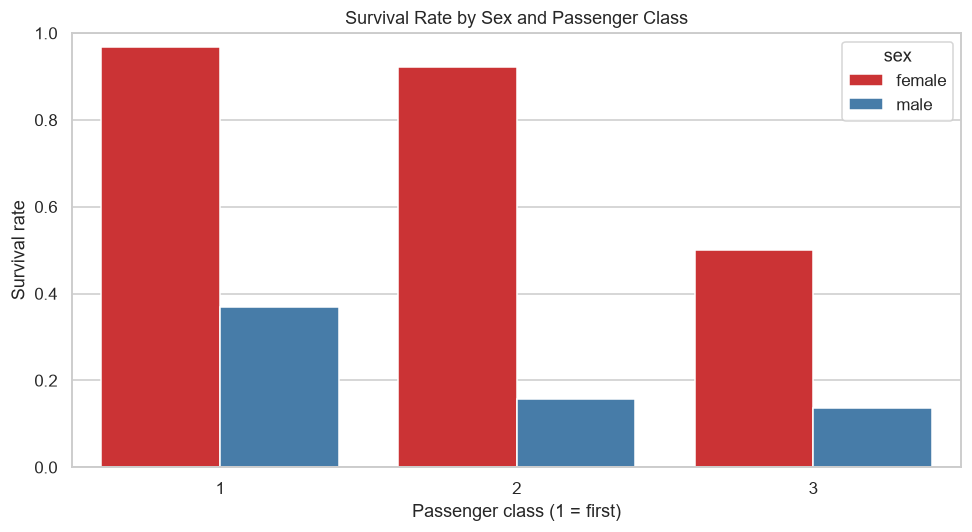

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=cleaned_df, x="pclass", y="survived", hue="sex",
            errorbar=None, ax=ax, palette="Set1")
ax.set_title("Survival Rate by Sex and Passenger Class")
ax.set_xlabel("Passenger class (1 = first)")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


**Interpretation.** The interaction of sex and class is stark: first-class
women had the highest survival rate, while third-class men had the lowest. Even within
the same class, females consistently out-survived males, though the gap narrows in third
class. The plot shows that sex and class jointly partition passengers into groups with
very different survival chances, so both features matter together rather than in isolation.


### Chart 6 — Age vs Fare coloured by survival


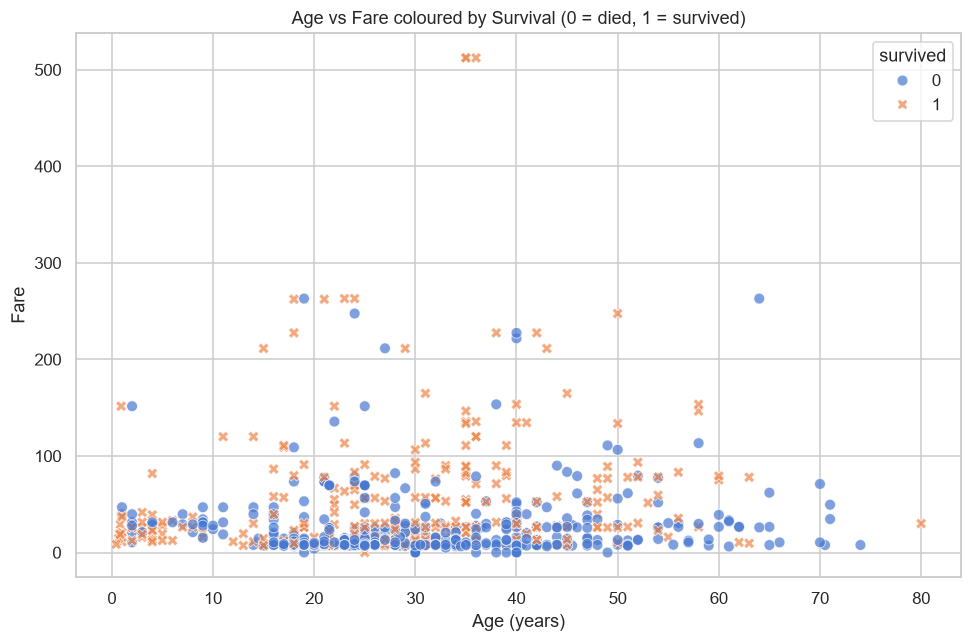

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=cleaned_df, x="age", y="fare", hue="survived",
                style="survived", alpha=0.7, ax=ax, s=50)
ax.set_title("Age vs Fare coloured by Survival (0 = died, 1 = survived)")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Fare")
plt.tight_layout()
plt.show()


**Interpretation.** Survival is concentrated at higher fare values regardless
of age, but within any fare band females (survived) still tend to appear at the lower end
of the age spectrum. The fare axis shows the right-skew described earlier — most
passengers paid modest fares while a long tail of expensive tickets extends upward. Age
alone shows almost no linear relationship with survival, consistent with the weak
age/survived correlation in the heatmap.


### Chart 7 — Fare distribution by passenger class


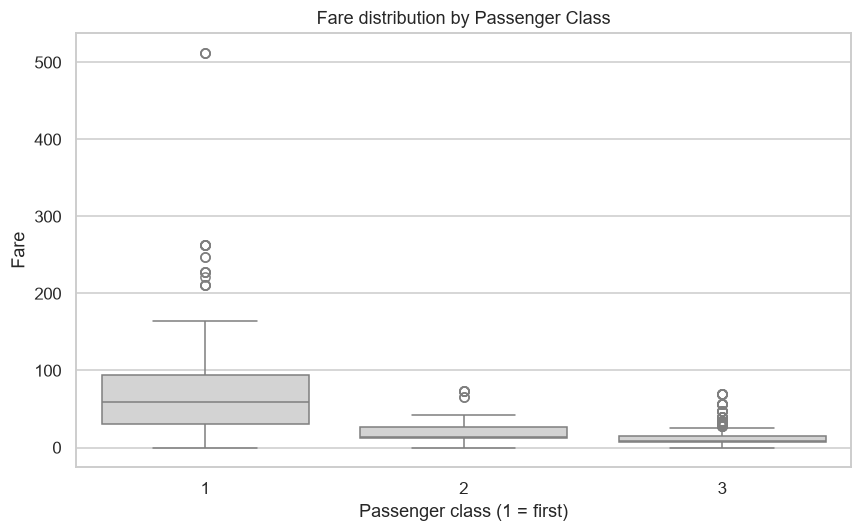

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=cleaned_df, x="pclass", y="fare", ax=ax, color="lightgray")
ax.set_title("Fare distribution by Passenger Class")
ax.set_xlabel("Passenger class (1 = first)")
ax.set_ylabel("Fare")
plt.tight_layout()
plt.show()


**Interpretation.** The median and spread of fare rise sharply from third to
first class, and first-class fares have a long upper tail of expensive tickets (the
outliers detected earlier), whereas third-class fares are compressed into a narrow low
range. This visually confirms the strong negative fare/pclass correlation and explains
why the overall fare distribution is right-skewed: a few first-class outliers inflate the
mean. The within-group comparison also makes the class-fare link far clearer than the
marginal fare distribution alone.


## 12. Standardization check (EDA only — NOT for modeling)

`age` and `fare` are standardized with `StandardScaler` and we confirm the result has
mean ≈ 0 and standard deviation ≈ 1. **This is an EDA sanity check only** and is not
intended to feed the later modeling preprocessing pipeline.


In [22]:
scaler = StandardScaler()
age_scaled = scaler.fit_transform(cleaned_df[["age"]])
fare_scaled = scaler.fit_transform(cleaned_df[["fare"]])

# NOTE: renamed to "*_z_*" so we do NOT clobber fare_mean / fare_median /
#       fare_mode / fare_skew defined in the fare-statistics section above
#       (those are needed later, un-standardised, in the summary).
age_z_mean = float(age_scaled.mean())
age_z_std = float(age_scaled.std())
fare_z_mean = float(fare_scaled.mean())
fare_z_std = float(fare_scaled.std())

print(f"Standardised age  -> mean: {age_z_mean:.8f}, std: {age_z_std:.8f}")
print(f"Standardised fare -> mean: {fare_z_mean:.8f}, std: {fare_z_std:.8f}")
print(f"Approximately mean==0 and std==1 ?  age: {abs(age_z_mean) < 1e-9 and abs(age_z_std - 1) < 1e-9}")
print(f"Approximately mean==0 and std==1 ?  fare: {abs(fare_z_mean) < 1e-9 and abs(fare_z_std - 1) < 1e-9}")

standardization = {
    "age": {"mean": age_z_mean, "std": age_z_std},
    "fare": {"mean": fare_z_mean, "std": fare_z_std},
}
standardization


Standardised age  -> mean: 0.00000000, std: 1.00000000
Standardised fare -> mean: 0.00000000, std: 1.00000000
Approximately mean==0 and std==1 ?  age: True
Approximately mean==0 and std==1 ?  fare: True


{'age': {'mean': 2.6375602114829364e-16, 'std': 1.0},
 'fare': {'mean': 1.3987061727561027e-16, 'std': 1.0}}

In [23]:
summary = {
    "shape_raw": list(df_raw.shape),
    "shape_clean": list(cleaned_df.shape),
    "missing_pct": {col: float(round(v, 2)) for col, v in missing_pct.items() if v > 0},
    "decisions": decisions,
    "age_iqr_outliers": int(age_outliers),
    "fare_iqr_outliers": int(fare_outliers),
    "fare_mean": round(fare_mean, 4),
    "fare_median": round(fare_median, 4),
    "fare_mode": round(fare_mode, 4),
    "fare_skew": round(fare_skew, 4),
    "top2_corr_pairs": [(p["feature_a"], p["feature_b"],
                         p["correlation"], p["abs_correlation"]) for p in pair_df.head(2).to_dict("records")],
    "corr_columns": corr_cols,
    "adult_male_excluded": "adult_male" not in corr_cols,
    "alone_excluded": "alone" not in corr_cols,
    "standardization": {k: {"mean": round(v["mean"], 6), "std": round(v["std"], 6)}
                        for k, v in standardization.items()},
}
print("EDA_SUMMARY_JSON_BEGIN")
print(json.dumps(summary, indent=2))
print("EDA_SUMMARY_JSON_END")


EDA_SUMMARY_JSON_BEGIN
{
  "shape_raw": [
    891,
    15
  ],
  "shape_clean": [
    889,
    15
  ],
  "missing_pct": {
    "age": 19.87,
    "embarked": 0.22,
    "deck": 77.22,
    "embark_town": 0.22
  },
  "decisions": {
    "age": "impute",
    "embarked": "drop rows",
    "deck": "encode missing as its own category ('Unknown')",
    "embark_town": "drop rows"
  },
  "age_iqr_outliers": 32,
  "fare_iqr_outliers": 114,
  "fare_mean": 32.0967,
  "fare_median": 14.4542,
  "fare_mode": 8.05,
  "fare_skew": 4.8014,
  "top2_corr_pairs": [
    [
      "pclass",
      "fare",
      -0.5482,
      0.5482
    ],
    [
      "sibsp",
      "parch",
      0.4145,
      0.4145
    ]
  ],
  "corr_columns": [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
  ],
  "adult_male_excluded": true,
  "alone_excluded": true,
  "standardization": {
    "age": {
      "mean": 0.0,
      "std": 1.0
    },
    "fare": {
      "mean": 0.0,
      "std": 1.0
    }
  }
}
EDA_SUMM